# Gold Price Prediction
`GLD` - Gold ETF<br>
`SPX` - S&P 500 index<br>
`USO` - oil<br>
`SLV` - silver ETF<br>
`EUR/USD`<br>
<br>
**Years**: 2008-2018, 2290 days

# Imports and loading dataset

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/Users/gabrielaslomiany/PycharmProjects/Not-So-Small-ML/gold-price-prediction/gold_price_data.csv')
print(df.shape)
df.head()

(2290, 6)


,Date,SPX,GLD,USO,SLV,EUR/USD
0,01/02/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,01/03/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,01/04/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,01/07/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,01/08/2008,1390.189941,86.779999,76.059998,15.590,1.557099


## Dataset overview

In [3]:
df.describe(include='all')

,Date,SPX,GLD,USO,SLV,EUR/USD
count,2290,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
unique,2290,NaN,NaN,NaN,NaN,NaN
top,01/02/2008,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN
mean,NaN,1654.315776,122.732875,31.842221,20.084997,1.283653
std,NaN,519.111540,23.283346,19.523517,7.092566,0.131547
min,NaN,676.530029,70.000000,7.960000,8.850000,1.039047
25%,NaN,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,NaN,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,NaN,2073.010070,132.840004,37.827501,22.882500,1.369971


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   str    
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), str(1)
memory usage: 107.5 KB


In [5]:
df.duplicated().sum()

np.int64(0)

## Handling Missing Values

In [6]:
df.isna().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

;) AMAZING

## Distribution Comparison

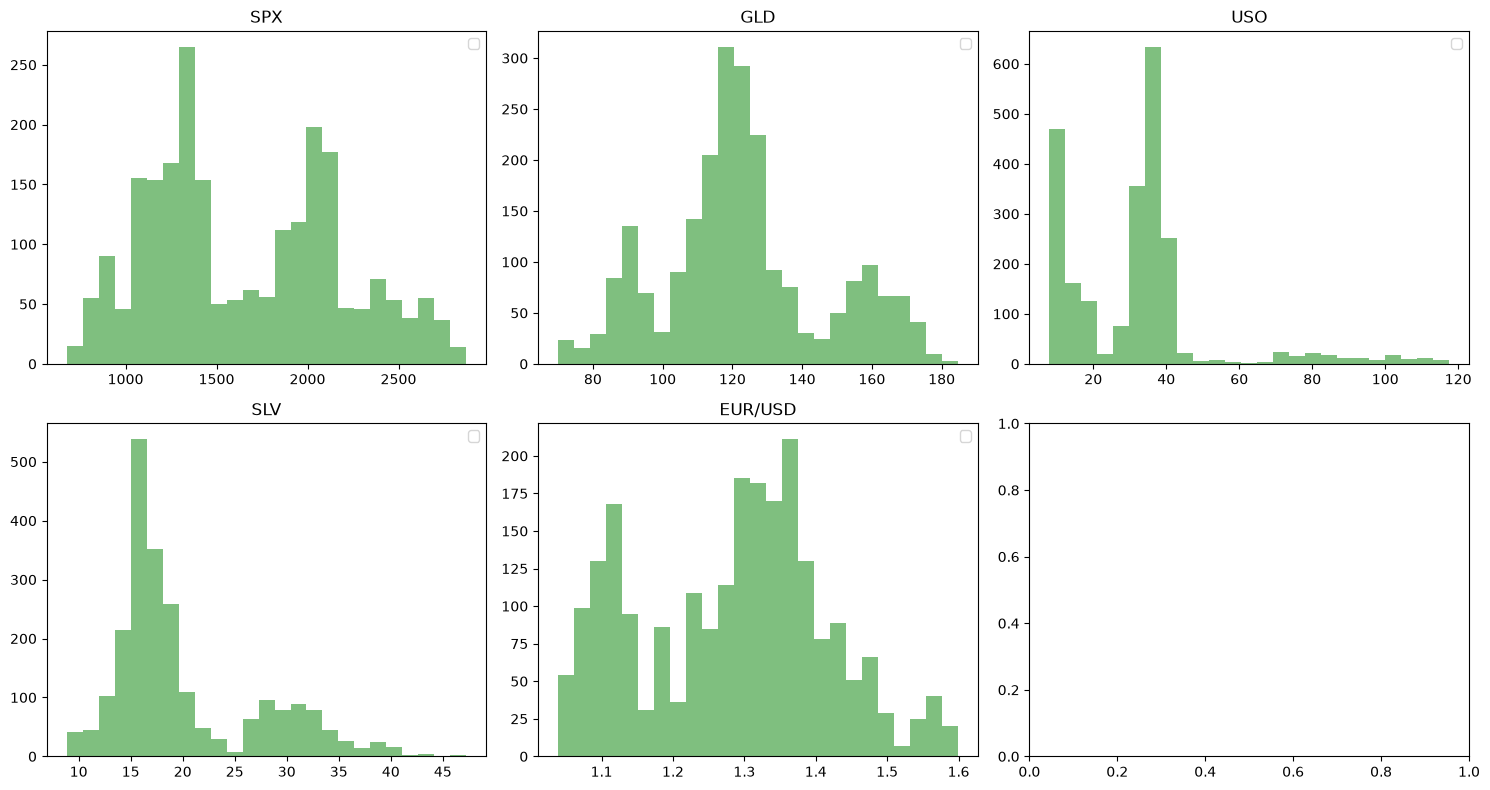

In [7]:
numeric_cols_for_plot = df.select_dtypes(include=[np.number]).columns[:6].tolist()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(numeric_cols_for_plot):
    if i >= 6: break
    if col in df.columns:
        axes[i].hist(df[col], bins=25, alpha=0.5, color='green')
    axes[i].set_title(col); axes[i].legend()
plt.tight_layout(); plt.show()

## Date Feature Engineering

In [8]:
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['DayOfWeek'] = df['Date'].dt.dayofweek + 1  # 1 = Monday, 7 = Sunday
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD,Day,Month,Year,DayOfWeek
0,2008-01-02,1447.160034,84.860001,78.470001,15.180,1.471692,2,1,2008,3
1,2008-01-03,1447.160034,85.570000,78.370003,15.285,1.474491,3,1,2008,4
2,2008-01-04,1411.630005,85.129997,77.309998,15.167,1.475492,4,1,2008,5
3,2008-01-07,1416.180054,84.769997,75.500000,15.053,1.468299,7,1,2008,1
4,2008-01-08,1390.189941,86.779999,76.059998,15.590,1.557099,8,1,2008,2


In [9]:
df = df.drop(columns=['Date'])

In [10]:
df.shape

(2290, 9)

## Scaling & Train Test

In [11]:
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

In [12]:
X = df.drop(columns=['GLD'])
y = df['GLD']
print('Features:', X.shape[1])
print('Target stats:'); print(y.describe().round(2))

Features: 8
Target stats:
count    2290.00
mean      122.73
std        23.28
min        70.00
25%       109.73
50%       120.58
75%       132.84
max       184.59
Name: GLD, dtype: float64


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2323)

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (1832, 8) Test: (458, 8)


## Models

In [15]:
results = []
models = {}

#### Linear Rregression

In [16]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

In [17]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

results.append({'Model': 'Linear Regression', 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE (%)': mape})
models['Linear Regression'] = ('scaled', lr)

print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R^2: {r2:.4f}')
print(f'MAPE: {mape:.2f}%')

MSE: 45.5995
RMSE: 6.7527
MAE: 5.2568
R^2: 0.9202
MAPE: 4.36%


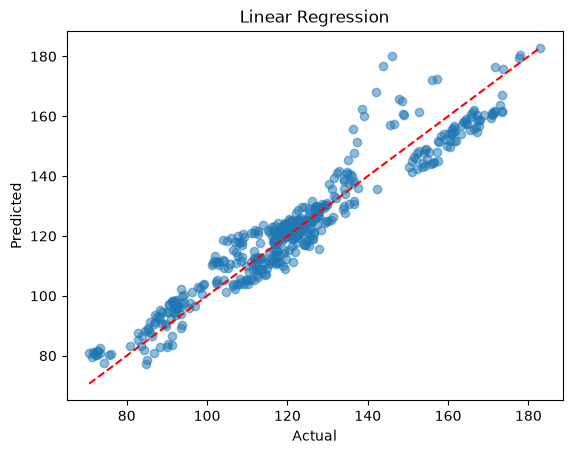

In [18]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linear Regression')
plt.show()

#### Decision Tree

In [19]:
dt = DecisionTreeRegressor()
dt.fit(X_train_scaled, y_train)
dt_y_pred = dt.predict(X_test_scaled)

In [20]:
mse = mean_squared_error(y_test, dt_y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, dt_y_pred)
r2 = r2_score(y_test, dt_y_pred)
mape = mean_absolute_percentage_error(y_test, dt_y_pred) * 100

results.append({'Model': 'Decision Tree', 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE (%)': mape})
models['Decision Tree'] = ('scaled', dt)

print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R^2: {r2:.4f}')
print(f'MAPE: {mape:.2f}%')

MSE: 5.1266
RMSE: 2.2642
MAE: 1.2992
R^2: 0.9910
MAPE: 1.08%


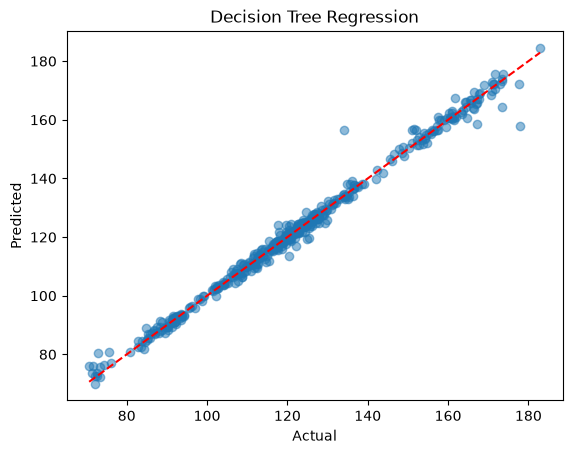

In [21]:
plt.scatter(y_test, dt_y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Decision Tree Regression')
plt.show()

g#### Random Forest

In [22]:
rf = RandomForestRegressor()
rf.fit(X_train_scaled, y_train)
rf_y_pred = rf.predict(X_test_scaled)

In [23]:
mse = mean_squared_error(y_test, rf_y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, rf_y_pred)
r2 = r2_score(y_test, rf_y_pred)
mape = mean_absolute_percentage_error(y_test, rf_y_pred) * 100

results.append({'Model': 'Random Forest', 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE (%)': mape})
models['Random Forest'] = ('scaled', rf)

print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R^2: {r2:.4f}')
print(f'MAPE: {mape:.2f}%')

MSE: 1.7245
RMSE: 1.3132
MAE: 0.9017
R^2: 0.9970
MAPE: 0.77%


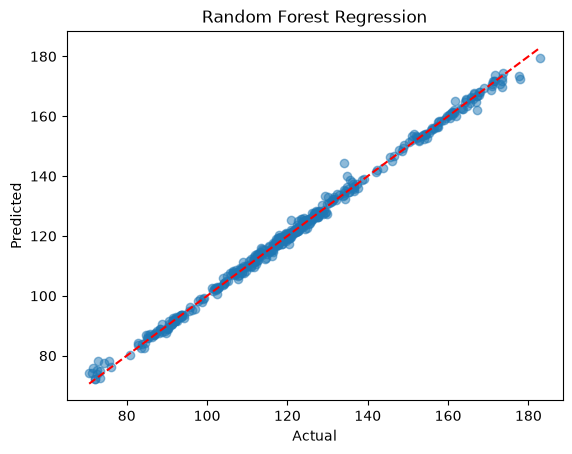

In [24]:
plt.scatter(y_test, rf_y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Random Forest Regression')
plt.show()

#### Gradient Boosting

In [25]:
gb = GradientBoostingRegressor()
gb.fit(X_train_scaled, y_train)
gb_y_pred = gb.predict(X_test_scaled)

In [26]:
mse = mean_squared_error(y_test, gb_y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, gb_y_pred)
r2 = r2_score(y_test, gb_y_pred)
mape = mean_absolute_percentage_error(y_test, gb_y_pred) * 100

results.append({'Model': 'Gradient Boosting', 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE (%)': mape})
models['Gradient Boosting'] = ('scaled', gb)

print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R^2: {r2:.4f}')
print(f'MAPE: {mape:.2f}%')

MSE: 4.7330
RMSE: 2.1755
MAE: 1.5927
R^2: 0.9917
MAPE: 1.34%


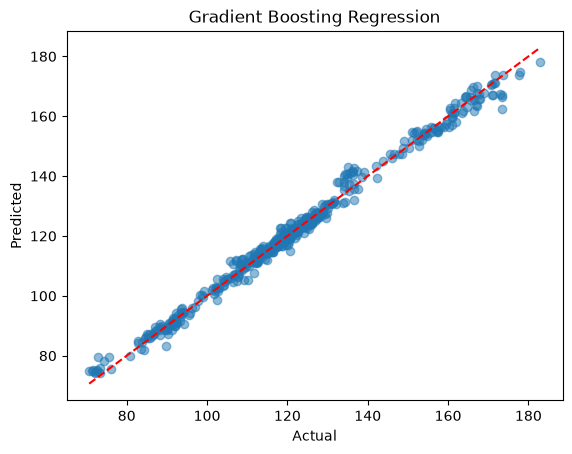

In [27]:
plt.scatter(y_test, gb_y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Gradient Boosting Regression')
plt.show()

## Model Comparison

In [29]:
comparison_df = pd.DataFrame(results).set_index('Model').sort_values('RMSE').round(2)
comparison_df

,MSE,RMSE,MAE,R2,MAPE (%)
Model,,,,,
Random Forest,1.72,1.31,0.90,1.00,0.77
Gradient Boosting,4.73,2.18,1.59,0.99,1.34
Decision Tree,5.13,2.26,1.30,0.99,1.08
Linear Regression,45.60,6.75,5.26,0.92,4.36


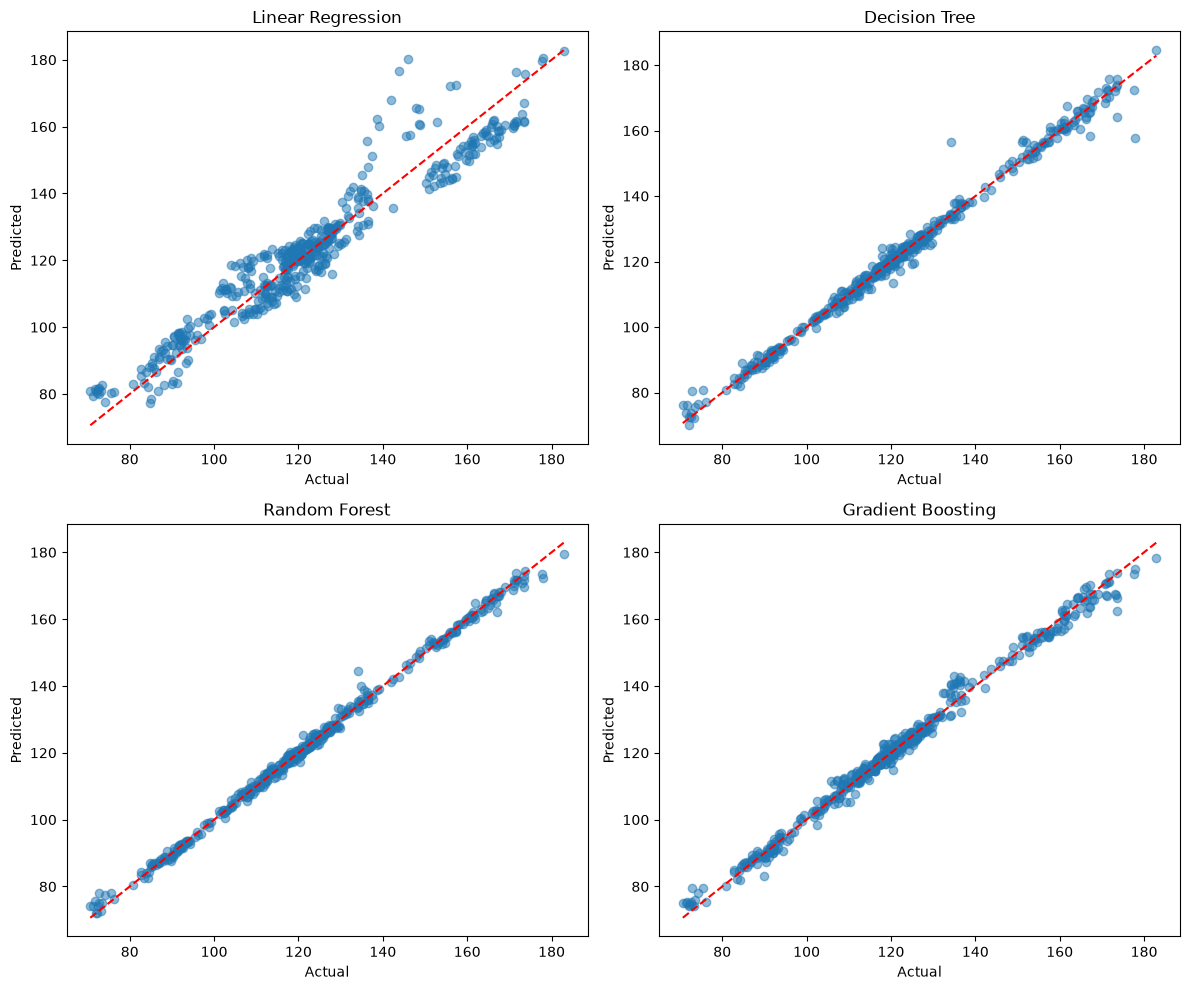

In [30]:
predictions = {
    'Linear Regression': y_pred,
    'Decision Tree': dt_y_pred,
    'Random Forest': rf_y_pred,
    'Gradient Boosting': gb_y_pred,
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()
for i, (name, preds) in enumerate(predictions.items()):
    axes[i].scatter(y_test, preds, alpha=0.5)
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
    axes[i].set_xlabel('Actual')
    axes[i].set_ylabel('Predicted')
    axes[i].set_title(name)
plt.tight_layout()
plt.show()

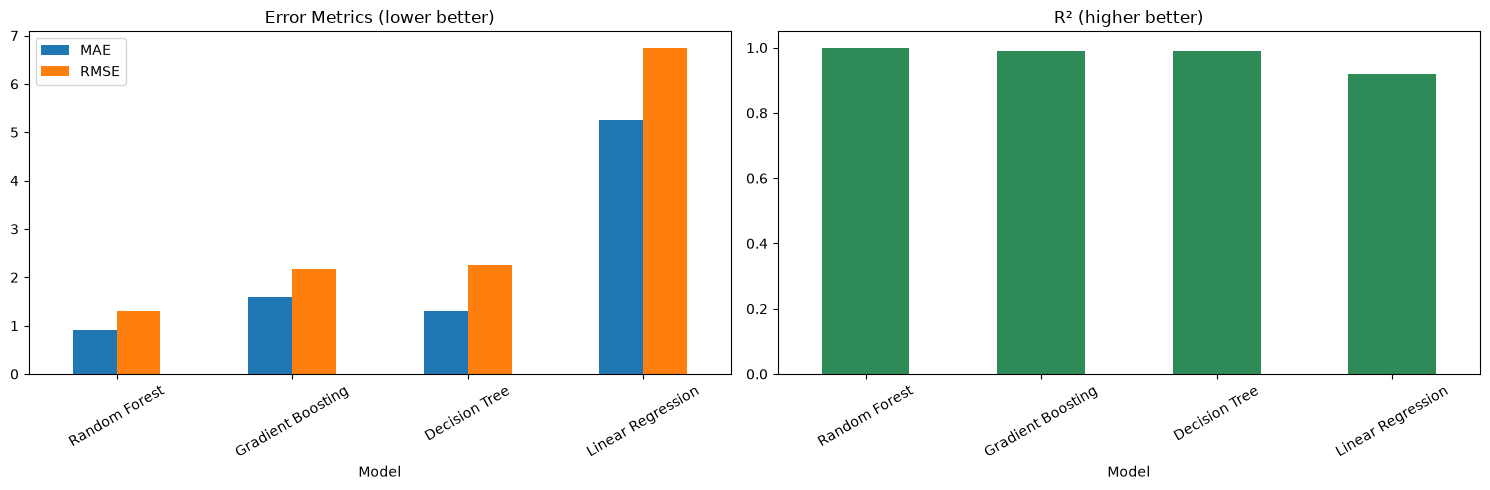

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
comparison_df[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Error Metrics (lower better)')
axes[0].tick_params(axis='x', rotation=30)
comparison_df[['R2']].plot(kind='bar', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('R² (higher better)')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

#### Best Model
`Random Forest` is the best model according to metrics with lowest `MAE` and `RMSE` and highest $R^2$.<br>
`Gradient Boost` is second best model.


## Feature Importance

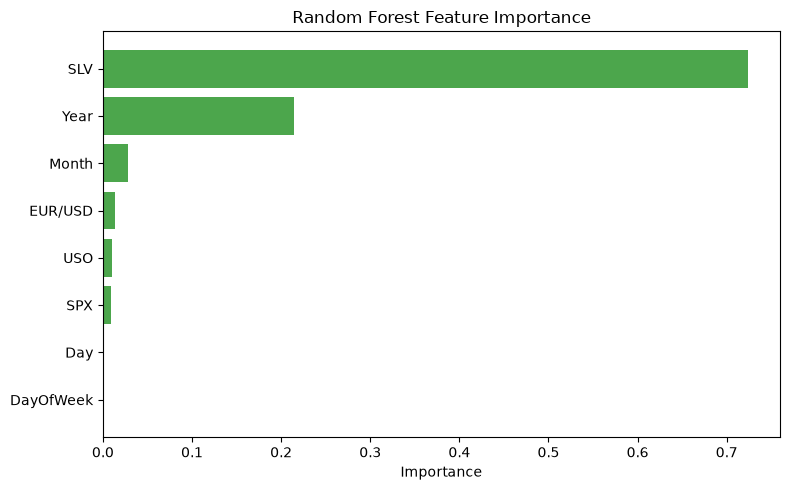

In [32]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importances.index, importances.values, color='green', alpha=0.7)
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

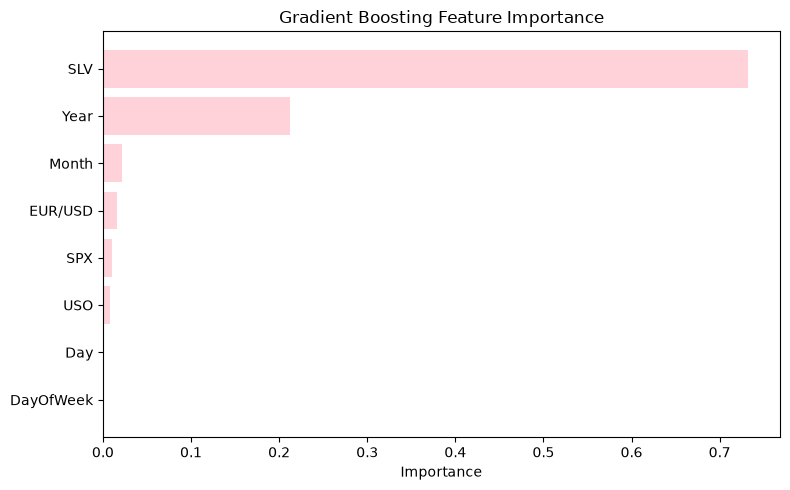

In [34]:
gb_importances = pd.Series(gb.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(gb_importances.index, gb_importances.values, color='pink', alpha=0.7)
plt.xlabel('Importance')
plt.title('Gradient Boosting Feature Importance')
plt.tight_layout()
plt.show()

## To do:
- model tuning rf and gb + compare
- prediction
- final summary
- conclusions

Extra:
- domain specific feature engineering
- better plots, experiment with visualisations